# From Earth to Plate - 04: US surplus food by sector (ReFED)

Maurice Baz & Dominika Bondyra - "From Earth to Plate", JH Data Patterns and Representations final project.

This notebook covers two deck slides using the ReFED sector table (**ReFED 2024 data, published in 2025 sector fact sheets**; geography: **United States**):

- **Slide 7** - where US surplus food arises (tons) versus where its associated GHG sits (MMt CO2e), by sector, plus an appendix ratio of associated GHG per ton of sector surplus.
- **Slide 10** - a schematic mechanism map contrasting personal habits with system and policy capacity (no quantitative lever comparison; see the caveats cell).

**Slide-to-figure mapping**

| Deck slot | Figure file | Format |
| --- | --- | --- |
| Slide 7 (main) | `figures/fig_slide07_surplus_tons_vs_ghg.png` | landscape, 16:9 |
| Slide 7 (appendix) | `figures/fig_appendix_slide07_associated_ghg_per_ton.png` | appendix |
| Slide 10 (main) | `figures/fig_slide10_personal_system_mechanisms.png` | landscape, 16:9 |

It replaces the earlier rough EDA (`refed_food_surplus_eda.ipynb`): one `pd.read_csv` on the actual CSV, one consistent dataframe name (`refed`), and deck-styled figures saved to `figures/`.

## Data, data year, and geography

- **Source file:** `data/ReFED_surplus_table(Surplus Data).csv` - **ReFED 2024 data, published in 2025 sector fact sheets.** Geography: **United States.** Five sectors (Residential, Farm, Manufacturing, Foodservice, Retail) with surplus tonnage (million tons), share of total surplus, associated GHG (million metric tons CO2e), and dollar value ($B). The GHG column header arrives mojibaked ("CO?e") and is renamed to the ASCII `GHG (MMt CO2e)` on load.
- **What ReFED measures:** *surplus food* - food and inedible parts sent to donation, animal feed, repurposing, composting, anaerobic digestion, and disposal. Surplus is broader than waste: this notebook says "waste" only where a destination (disposal) or the name of a law literally concerns waste.
- **What the GHG column is:** the GHG that ReFED's model associates with each sector's surplus. It is a modeled "associated GHG" total, not a measurement and not an avoided-emissions estimate.

In [1]:
# Setup: imports, robust paths, house chart style (shared across all four notebooks)
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path.cwd() if (Path.cwd()/'data').exists() else Path.cwd().parent
DATA, FIGS = ROOT/'data', ROOT/'figures'
FIGS.mkdir(exist_ok=True)

# House palette
SURFACE  = '#fcfcfb'   # figure + axes background
INK      = '#0b0b0b'   # primary ink (titles, callouts)
SUB      = '#52514e'   # secondary ink (subtitles, value labels)
MUT      = '#898781'   # muted (ticks, captions)
BASELINE = '#c3c2b7'   # axis baseline
GRID     = '#e1e0d9'   # hairline grid
BLUE     = '#2a78d6'   # slot 1 / sequential default hue
GREEN    = '#008300'   # slot 2
LIGHTBLUE = '#9ec5f4'  # de-emphasis step in the blue family

mpl.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE,
    'savefig.facecolor': SURFACE, 'savefig.dpi': 200, 'savefig.bbox': 'tight',
    'font.family': 'sans-serif', 'font.sans-serif': ['Segoe UI', 'DejaVu Sans'],
    'axes.edgecolor': BASELINE, 'axes.linewidth': 0.8,
    'xtick.color': MUT, 'ytick.color': MUT, 'axes.labelcolor': MUT,
    'text.color': INK,
    'grid.color': GRID, 'grid.linewidth': 0.8, 'grid.linestyle': '-',
    'axes.grid': False, 'figure.dpi': 110,
})

def style_barh_ax(ax):
    """House style for a horizontal-bar axes: hairline grid on the value axis
    only, drawn behind the data; no chart border box; baseline at x = 0."""
    ax.set_axisbelow(True)
    ax.grid(axis='x')
    for side in ('top', 'right', 'bottom'):
        ax.spines[side].set_visible(False)
    ax.spines['left'].set_color(BASELINE)
    ax.tick_params(length=0, labelsize=9.5)

def fmt1(v):
    """One decimal where it aids reading; drop it for effectively-integer values."""
    return f'{v:,.0f}' if abs(v - round(v)) < 0.05 else f'{v:,.1f}'

def save_fig(fig, name):
    out = FIGS/name
    fig.savefig(out, dpi=200, bbox_inches='tight', facecolor=SURFACE)
    print('saved', out)

In [2]:
# Load the ReFED sector table; repair the mojibaked GHG header on load
def read_refed(path):
    try:
        return pd.read_csv(path, encoding='utf-8')
    except UnicodeDecodeError:
        return pd.read_csv(path, encoding='cp1252')

refed = read_refed(DATA/'ReFED_surplus_table(Surplus Data).csv')
refed = refed.rename(columns={c: 'GHG (MMt CO2e)' for c in refed.columns if 'GHG' in c})
refed['pct_of_total'] = refed['% of total'].str.rstrip('%').astype(float)

total_tons = refed['Surplus (M tons)'].sum()
total_ghg = refed['GHG (MMt CO2e)'].sum()

# Derived shares for BOTH measures, and the descriptive per-ton ratio.
# MMt CO2e per M tons of surplus == t CO2e per ton of surplus (the M cancels).
refed['pct_tons'] = 100 * refed['Surplus (M tons)'] / total_tons
refed['pct_ghg'] = 100 * refed['GHG (MMt CO2e)'] / total_ghg
refed['co2e_per_ton'] = refed['GHG (MMt CO2e)'] / refed['Surplus (M tons)']

# Sanity assertions - any violation raises and stops the notebook
assert refed.shape[0] == 5, 'expected exactly 5 sectors'
assert refed['Sector'].is_unique, 'sector names must be unique'
assert (refed['Surplus (M tons)'] >= 0).all(), 'surplus tons must all be nonnegative'
assert (refed['GHG (MMt CO2e)'] >= 0).all(), 'associated GHG must all be nonnegative'
assert abs(refed['pct_tons'].sum() - 100) < 0.01, 'tonnage shares must sum to ~100'
assert abs(refed['pct_ghg'].sum() - 100) < 0.01, 'GHG shares must sum to ~100'
assert abs(refed['pct_of_total'].sum() - 100) < 0.5, "the file's own % column should sum to ~100"

print(f'US totals (ReFED 2024 data, published in 2025 sector fact sheets): '
      f'{total_tons:.1f} M tons of surplus food, {total_ghg:.1f} MMt CO2e associated GHG')
refed.sort_values('Surplus (M tons)', ascending=False)

US totals (ReFED 2024 data, published in 2025 sector fact sheets): 70.7 M tons of surplus food, 220.9 MMt CO2e associated GHG


,Sector,Surplus (M tons),% of total,GHG (MMt CO2e),Value ($B),pct_of_total,pct_tons,pct_ghg,co2e_per_ton
0,Residential,23.50,33.2%,100.00,141.0,33.2,33.224940,45.277551,4.255319
1,Farm,16.90,23.9%,3.56,13.4,23.9,23.893680,1.611881,0.210651
2,Manufacturing,13.20,18.6%,38.60,42.7,18.6,18.662519,17.477135,2.924242
3,Foodservice,12.50,17.7%,63.60,157.0,17.7,17.672840,28.796523,5.088000
4,Retail,4.63,6.5%,15.10,30.3,6.5,6.546020,6.836910,3.261339


## Slide 7 - surplus tons versus associated GHG

ReFED sizes each sector's surplus food two ways: tonnage and associated GHG (ReFED 2024 data, published in 2025 sector fact sheets; United States). We plot the two measures as side-by-side panels with the **same fixed row order** (sorted by surplus tons, descending) in both panels - that choice is the chart. If associated GHG tracked tonnage, the right panel would step down monotonically like the left; instead the order scrambles, and the fixed rows make the divergence visible at a glance.

Style choices: each panel shows exactly one measure, so each keeps a single hue rather than a color per bar; the story rows (Foodservice, Farm) are called out with annotations, not color changes; with only five bars per panel, each bar carries a direct value label so the panels read without an axis hunt.

saved C:\Users\M\code\JH-2026-Final-Project\figures\fig_slide07_surplus_tons_vs_ghg.png


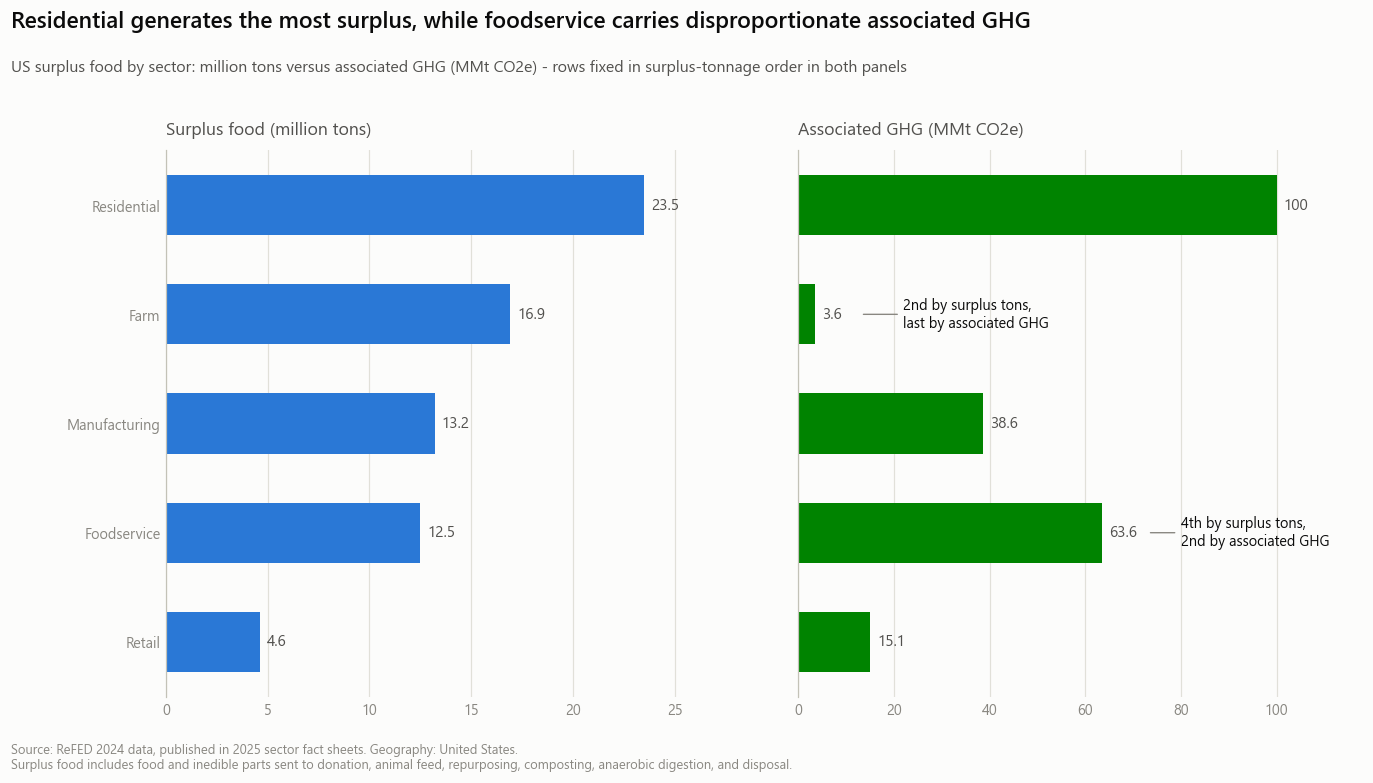

In [3]:
# Figure A (slide 7, main deck): two panels, same fixed sector order (by surplus tons, desc)
order = refed.sort_values('Surplus (M tons)', ascending=False).reset_index(drop=True)
y = np.arange(len(order))
fs_i = int(order.index[order['Sector'] == 'Foodservice'][0])
farm_i = int(order.index[order['Sector'] == 'Farm'][0])

fig, axes = plt.subplots(1, 2, figsize=(12.8, 7.2), sharey=True)
fig.subplots_adjust(left=0.12, right=0.97, top=0.80, bottom=0.11, wspace=0.12)
panels = [
    (axes[0], 'Surplus (M tons)', 'Surplus food (million tons)', BLUE),
    (axes[1], 'GHG (MMt CO2e)', 'Associated GHG (MMt CO2e)', GREEN),
]
for ax, col, header, hue in panels:
    vals = order[col].to_numpy()
    ax.barh(y, vals, height=0.55, color=hue)
    style_barh_ax(ax)
    ax.set_title(header, loc='left', fontsize=11.5, color=SUB, pad=10)
    ax.set_xlim(0, vals.max() * 1.18)
    for yi, v in zip(y, vals):
        ax.text(v + vals.max() * 0.015, yi, fmt1(v),
                va='center', ha='left', fontsize=10, color=SUB)
axes[0].set_yticks(y, order['Sector'])
axes[0].invert_yaxis()   # biggest surplus on top; sharey flips both panels

# Story annotations live on the associated-GHG panel: the ranking divergence
axes[1].annotate('4th by surplus tons,\n2nd by associated GHG',
                 xy=(73, fs_i), xytext=(80, fs_i), va='center', ha='left',
                 fontsize=9.5, color=INK,
                 arrowprops=dict(arrowstyle='-', color=MUT, lw=0.9))
axes[1].annotate('2nd by surplus tons,\nlast by associated GHG',
                 xy=(13, farm_i), xytext=(22, farm_i), va='center', ha='left',
                 fontsize=9.5, color=INK,
                 arrowprops=dict(arrowstyle='-', color=MUT, lw=0.9))

fig.text(0.01, 0.955,
         'Residential generates the most surplus, while foodservice carries disproportionate associated GHG',
         ha='left', fontsize=15, fontweight=600, color=INK)
fig.text(0.01, 0.90,
         'US surplus food by sector: million tons versus associated GHG (MMt CO2e) - '
         'rows fixed in surplus-tonnage order in both panels',
         ha='left', fontsize=10.5, color=SUB)
fig.text(0.01, 0.015,
         'Source: ReFED 2024 data, published in 2025 sector fact sheets. Geography: United States.\n'
         'Surplus food includes food and inedible parts sent to donation, animal feed, repurposing, '
         'composting, anaerobic digestion, and disposal.',
         ha='left', va='bottom', fontsize=8.5, color=MUT)
save_fig(fig, 'fig_slide07_surplus_tons_vs_ghg.png')
plt.show()

**Takeaway.** Residential generates the most surplus food on BOTH measures: 23.5 M tons (33.2% of the 70.7 M-ton US total) and 100 MMt CO2e of the 220.9 MMt total associated GHG. Below the top row the two rankings diverge: Farm is 2nd by tonnage (16.9 M tons) yet last by associated GHG (3.56 MMt), while Foodservice is 4th by tonnage (12.5 M tons) yet 2nd by associated GHG (63.6 MMt) - a disproportionate share relative to its tonnage. Tonnage alone is not a map of where the associated GHG sits; the appendix ratio below describes the per-ton differences.

### Appendix - associated GHG per ton of sector surplus

Dividing each sector's associated GHG by its surplus tonnage gives a **descriptive ratio**: MMt CO2e per M tons, which is simply t CO2e per ton of surplus (the millions cancel). It describes how much GHG ReFED's model associates with an average surplus ton in each sector.

It is **not** a savings estimate: preventing a ton of surplus in a sector cannot be assumed to avoid that amount of emissions. Sector differences in the ratio can reflect the mix of foods in each sector's surplus, the upstream supply-chain stages the food has already accrued by the time the surplus occurs, and each sector's current management destinations.

saved C:\Users\M\code\JH-2026-Final-Project\figures\fig_appendix_slide07_associated_ghg_per_ton.png


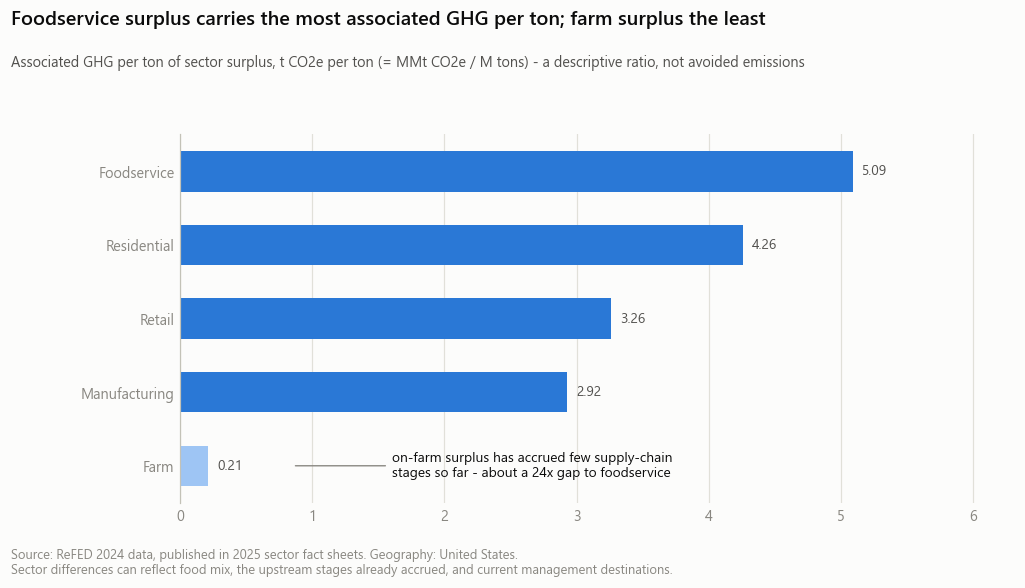

In [4]:
# Figure B (slide 7 appendix): associated GHG per ton of sector surplus, ranked
inten = refed.sort_values('co2e_per_ton', ascending=False).reset_index(drop=True)
top_vs_farm = inten['co2e_per_ton'].iloc[0] / inten['co2e_per_ton'].iloc[-1]

fig, ax = plt.subplots(figsize=(9.6, 5.4))
fig.subplots_adjust(left=0.17, right=0.96, top=0.76, bottom=0.14)
yi_pos = np.arange(len(inten))
colors = [LIGHTBLUE if s == 'Farm' else BLUE for s in inten['Sector']]
ax.barh(yi_pos, inten['co2e_per_ton'], height=0.55, color=colors)
style_barh_ax(ax)
ax.set_yticks(yi_pos, inten['Sector'])
ax.invert_yaxis()
ax.set_xlim(0, inten['co2e_per_ton'].max() * 1.24)
for yy, v in zip(yi_pos, inten['co2e_per_ton']):
    ax.text(v + 0.07, yy, f'{v:.2f}', va='center', ha='left', fontsize=9, color=SUB)

ax.annotate(
    f'on-farm surplus has accrued few supply-chain\n'
    f'stages so far - about a {top_vs_farm:.0f}x gap to foodservice',
    xy=(0.85, len(inten) - 1), xytext=(1.6, len(inten) - 1), va='center', ha='left',
    fontsize=9, color=INK, arrowprops=dict(arrowstyle='-', color=MUT, lw=0.9))

fig.text(0.01, 0.945,
         'Foodservice surplus carries the most associated GHG per ton; farm surplus the least',
         ha='left', fontsize=13, fontweight=600, color=INK)
fig.text(0.01, 0.875,
         'Associated GHG per ton of sector surplus, t CO2e per ton (= MMt CO2e / M tons) - '
         'a descriptive ratio, not avoided emissions',
         ha='left', fontsize=9.5, color=SUB)
fig.text(0.01, 0.015,
         'Source: ReFED 2024 data, published in 2025 sector fact sheets. Geography: United States.\n'
         'Sector differences can reflect food mix, the upstream stages already accrued, and current '
         'management destinations.',
         ha='left', va='bottom', fontsize=8.5, color=MUT)
save_fig(fig, 'fig_appendix_slide07_associated_ghg_per_ton.png')
plt.show()

**Reading the ratio.** Foodservice surplus carries the most associated GHG per ton (5.09 t CO2e per ton), then Residential (4.26), Retail (3.26), Manufacturing (2.92), with Farm far lower (0.21) - roughly a 24x spread top to bottom. This is a descriptive comparison of ReFED's modeled totals, not an avoided-emissions rate: it does not say that preventing a ton of foodservice surplus would avoid 5.09 t CO2e. The differences can reflect each sector's food mix, the upstream stages the food has already accrued by the time surplus occurs, and how each sector's surplus is currently managed.

## Slide 10 - personal choices and recovery systems

Slide 10 closes the deck by contrasting two kinds of response to surplus food. We present them as a **schematic mechanism map**, not a quantitative comparison: the repository's data does not support causal avoided-emissions estimates for either side, so no lever magnitudes are computed.

- **Personal mechanisms** are recurring individual habits: lower-impact substitutions repeated across the year, planning and storing food so it gets eaten, and using what was purchased.
- **System mechanisms** are infrastructure and agreements that operate regardless of any one person's behavior: preventing surplus before it occurs, food-recovery agreements between generators of edible surplus and recovery organizations, cold storage and transportation, and pantry/recovery capacity to absorb what is recovered.

**Policy example - California SB 1383** (Short-Lived Climate Pollutants Reduction Act, 2016). The 20% edible-food-recovery figure in SB 1383 is a **California statewide collective goal** - it is not a requirement on any individual generator, business, sector, or jurisdiction. Covered commercial generators must arrange to recover the maximum amount of edible food that would otherwise be disposed. SB 1383 is a real-world instance of the system column's mechanisms (recovery agreements and recovery capacity); it is cited here as context only, and no emissions-benefit arithmetic is done with it.

saved C:\Users\M\code\JH-2026-Final-Project\figures\fig_slide10_personal_system_mechanisms.png


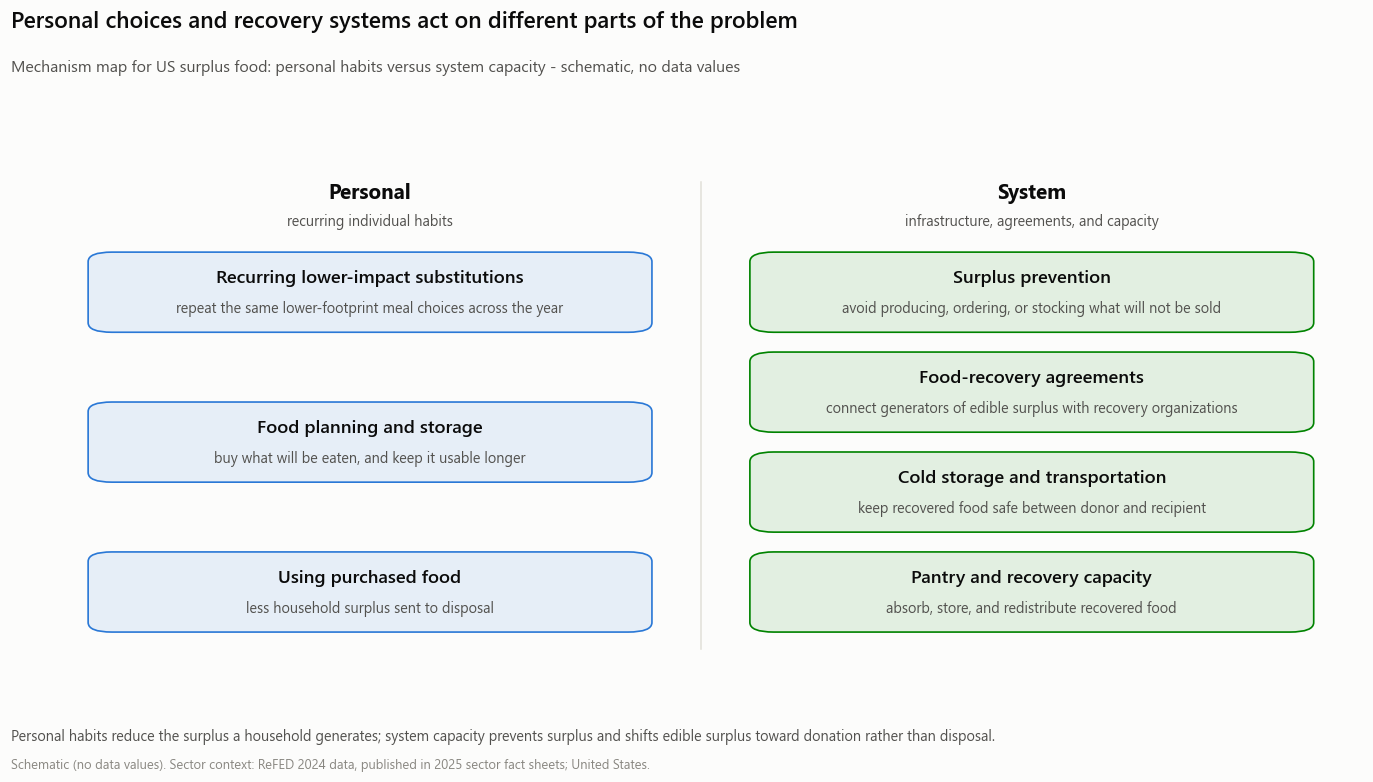

In [5]:
# Figure C (slide 10, main deck): schematic mechanism map - personal vs system.
# Non-quantitative by design: rounded boxes and text only, no data values.
from matplotlib.patches import FancyBboxPatch

personal_items = [
    ('Recurring lower-impact substitutions',
     'repeat the same lower-footprint meal choices across the year'),
    ('Food planning and storage',
     'buy what will be eaten, and keep it usable longer'),
    ('Using purchased food',
     'less household surplus sent to disposal'),
]
system_items = [
    ('Surplus prevention',
     'avoid producing, ordering, or stocking what will not be sold'),
    ('Food-recovery agreements',
     'connect generators of edible surplus with recovery organizations'),
    ('Cold storage and transportation',
     'keep recovered food safe between donor and recipient'),
    ('Pantry and recovery capacity',
     'absorb, store, and redistribute recovered food'),
]

fig, ax = plt.subplots(figsize=(12.8, 7.2))
fig.subplots_adjust(left=0.03, right=0.97, top=0.80, bottom=0.13)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

def draw_column(x0, width, header, subheader, items, hue, y_top=0.80, y_bottom=0.10, h=0.135):
    ax.text(x0 + width/2, 0.92, header, ha='center', va='center',
            fontsize=13.5, fontweight=700, color=INK)
    ax.text(x0 + width/2, 0.865, subheader, ha='center', va='center',
            fontsize=9.5, color=SUB)
    centers = np.linspace(y_top - h/2, y_bottom + h/2, len(items))
    for (main, sub), yc in zip(items, centers):
        ax.add_patch(FancyBboxPatch(
            (x0, yc - h/2), width, h,
            boxstyle='round,pad=0.008,rounding_size=0.018',
            linewidth=1.1, edgecolor=hue,
            facecolor=mpl.colors.to_rgba(hue, 0.10), clip_on=False))
        ax.text(x0 + width/2, yc + 0.027, main, ha='center', va='center',
                fontsize=12, fontweight=600, color=INK)
        ax.text(x0 + width/2, yc - 0.031, sub, ha='center', va='center',
                fontsize=9.5, color=SUB)

draw_column(0.045, 0.41, 'Personal', 'recurring individual habits', personal_items, BLUE)
draw_column(0.545, 0.41, 'System', 'infrastructure, agreements, and capacity', system_items, GREEN)
ax.plot([0.5, 0.5], [0.06, 0.94], color=GRID, lw=1)

fig.text(0.01, 0.955,
         'Personal choices and recovery systems act on different parts of the problem',
         ha='left', fontsize=15, fontweight=600, color=INK)
fig.text(0.01, 0.90,
         'Mechanism map for US surplus food: personal habits versus system capacity - schematic, no data values',
         ha='left', fontsize=10.5, color=SUB)
fig.text(0.01, 0.055,
         'Personal habits reduce the surplus a household generates; system capacity prevents surplus '
         'and shifts edible surplus toward donation rather than disposal.',
         ha='left', fontsize=9.5, color=SUB)
fig.text(0.01, 0.02,
         'Schematic (no data values). Sector context: ReFED 2024 data, published in 2025 sector '
         'fact sheets; United States.',
         ha='left', fontsize=8.5, color=MUT)
save_fig(fig, 'fig_slide10_personal_system_mechanisms.png')
plt.show()

**Takeaway.** Personal habits and recovery systems act on different parts of the problem. Personal mechanisms reduce the surplus a household generates in the first place; system mechanisms prevent surplus upstream and shift edible surplus toward donation rather than disposal. Neither side is quantified here - the diagram is a schematic map of mechanisms, not a comparison of magnitudes.

## Caveats and limitations

- **Modeled estimates.** The sector figures are model outputs (ReFED 2024 data, published in 2025 sector fact sheets), not direct measurements; we take the sector table as given without re-deriving it.
- **Surplus is not waste.** ReFED's measure is *surplus food*: food and inedible parts sent to donation, animal feed, repurposing, composting, anaerobic digestion, and disposal. Only part of surplus is disposed, and not all of it is avoidable.
- **Associated GHG is not avoidable GHG.** The GHG column blends ReFED's model assumptions about upstream production and downstream management. GHG *associated with* surplus is not GHG *avoided* if the surplus were prevented; this notebook makes no avoided-emissions claims from these totals.
- **The per-ton ratio is descriptive.** Sector differences in associated GHG per ton can reflect food mix, the upstream stages already accrued, and current management destinations - not the marginal effect of preventing one ton.
- **SB 1383 scope.** SB 1383 is a California law. Its 20% edible-food-recovery figure is a statewide collective goal, not a per-generator, per-business, per-sector, or per-jurisdiction requirement; covered commercial generators must arrange recovery of the maximum amount of edible food that would otherwise be disposed. No emissions-benefit arithmetic is done with SB 1383 anywhere in this project.

## Sources

- **ReFED** - ReFED 2024 data, published in 2025 sector fact sheets; US surplus food by sector. Sector fact sheets:
  - Farm: https://refed.org/downloads/by-sector-farm-2025.pdf
  - Manufacturing: https://refed.org/downloads/by-sector-manufacturing-2025.pdf
  - Retail: https://refed.org/downloads/by-sector-retail-2025.pdf
  - Foodservice: https://refed.org/downloads/by-sector-foodservice-2025.pdf
  - Residential: https://refed.org/downloads/by-sector-residential-2025.pdf
  - ReFED Insights Engine: https://insights.refed.org
- **California SB 1383 (2016)** - Short-Lived Climate Pollutants Reduction Act. Its 20% edible-food-recovery figure is a California statewide collective goal (not a per-generator, per-business, per-sector, or per-jurisdiction requirement); covered commercial generators must arrange recovery of the maximum amount of edible food that would otherwise be disposed.